In [11]:
"""

Robko 01 - ROS2 Control Software

Copyright (C) [2025] [Orlin Dimitrov]

This program is free software: you can redistribute it and/or modify
it under the terms of the GNU General Public License as published by
the Free Software Foundation, either version 3 of the License, or
(at your option) any later version.

This program is distributed in the hope that it will be useful,
but WITHOUT ANY WARRANTY; without even the implied warranty of
MERCHANTABILITY or FITNESS FOR A PARTICULAR PURPOSE.  See the
GNU General Public License for more details.

You should have received a copy of the GNU General Public License
along with this program.  If not, see <http://www.gnu.org/licenses/>.

"""

# https://github.com/robko01/robko01_ros2/blob/main/urdf/robko01.urdf
# https://www.geeksforgeeks.org/how-to-install-jupyter-notebook-in-linux/
# https://www.geeksforgeeks.org/using-matplotlib-with-jupyter-notebook/
# https://mymodelrobot.appspot.com/5629499534213120
# https://github.com/Phylliade/ikpy

import os
import time
import math
import tempfile

import numpy as np
from ikpy.chain import Chain
import ikpy.utils.plot as plot_utils
import xacro

tmp_urdf = None
ik = None
kinematics_chain = None
active_links_mask=[False, True, True, True, True, True, False]
static_joint_offset = [0.0, -9.363956800186491, -11.340518369898835, 4.177941350622293, 89.99609796746472, 7.652737291429329, 0.0]

# base_world = [0.213, 0.0, 0.380] # in [mm]
base_world = [0.213, 0.0, 0.380] # in [mm]

# Conversion tables from radians to steps.
conversion_table_rad = [1125, 1125, 672, 241, 241]

# Conversion table from degreece to steps.
conversion_table_deg = [19.64, 19.64, 11.55, 4.27, 4.27]

def degrees_to_radians(degrees_list):
    return [math.radians(degree) for degree in degrees_list]

def radians_to_steps(radians_list):
    global conversion_table_rad
    result = []
    for key, value in enumerate(radians_list):
        result.append(int(conversion_table_rad[key]*value))
    return result

def degrees_to_steps(degrees_list):
    global conversion_table_deg
    result = []
    for key, value in enumerate(degrees_list):
        result.append(int(conversion_table_deg[key]*value))
    return result

def to_actiual_position(target_position):
    global base_world
    return np.add(np.array(base_world), np.array(target_position)) #.tolist()

def load_urdf():
    global tmp_urdf
    result = False
    try:
        # Load XACRO model file.
        xacro_robot_model_path = os.path.join("description", "robko01.urdf.xacro")
    
        # Process xacro to URDF.
        robot_description = xacro.process_file(xacro_robot_model_path).toxml()
    
        # Write to temporary file.
        tmp_urdf = tempfile.NamedTemporaryFile(delete=False, suffix=".urdf")
        tmp_urdf.write(robot_description.encode("utf-8"))
        tmp_urdf.close()
        print(tmp_urdf.name)
        # urdf_robot_model_path = os.path.join("urdf", "robko01.urdf")
        result = True
    except Exception as e:
        print(e)

    return result

def init_ik():
    global kinematics_chain
    # Load the kinematics description.
    kinematics_chain = Chain.from_urdf_file(
        tmp_urdf.name,
        active_links_mask=active_links_mask)

def compute(target_position, target_orientation):
    global ik, kinematics_chain, active_links_mask

    # Inverst calculations.
    ik = kinematics_chain.inverse_kinematics(target_position, target_orientation, orientation_mode="Y")
    
    # Forward calculations.
    fk = kinematics_chain.forward_kinematics(ik)
    # print(f"Computed position: {fk[:3, 3]}, original position : {target_position}")
    # print("Computed position (readable) : %s" % [ "%.2f" % elem for elem in fk[:3, 3] ])

    robot_angles = list(map(lambda r: math.degrees(r), ik.tolist()))

    # Static joint offset.
    robot_angles = np.add(np.array(robot_angles), np.array(static_joint_offset)).tolist()

    return robot_angles

def draw(target_position):
    global ik, kinematics_chain
    # Plot the data.
    # %matplotlib widget
    #%matplotlib widget
    import matplotlib.pyplot as plt

    fig, ax = plot_utils.init_3d_figure()
    fig.set_figheight(9)  
    fig.set_figwidth(13)
    print(target_position)
    kinematics_chain.plot(ik, ax, target=target_position)
    plt.xlim(-0.5, 0.5)
    plt.ylim(-0.5, 0.5)
    ax.set_zlim(0, 0.6)
    plt.ion()

# load the robot model.
load_urdf()

# Initialise the IK.
init_ik()

/tmp/tmpbl0lucni.urdf


[0.213 0.    0.38 ]
Degs: [-9.36395569857351, -7.561899046608613, -11.804740936737419, 102.1988325818885, 97.65273049612192]
Steps: [-183, -148, -138, 429, 410]
Rads: [-0.16343185795099346, -0.13198003606674044, -0.2060315966910276, 1.7837061202484117, 1.7043616707200033]
Steps: [-183, -148, -136, 436, 416]


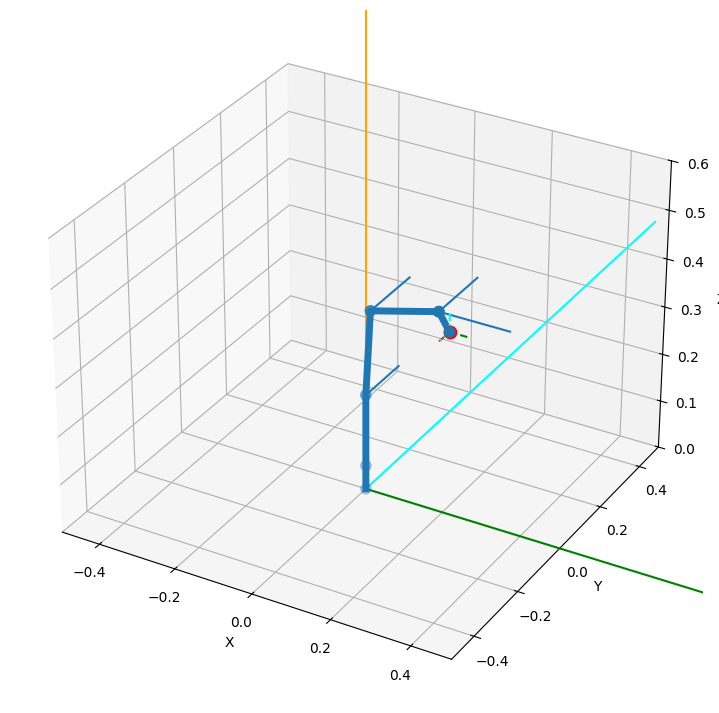

In [14]:
# target position and orientation.
# target_position = [ 0.175, 0.0, 0.380]
# target_position = [ 0.220, 0.0, 0.380]
target_position = [0.0, 0.0, 0.0]
target_orientation = [0.0, 0.0, 1.5708]

actual_position = to_actiual_position(target_position)

# Draw the target position.
draw(actual_position)

# Compute invers kinematics based on URDF.
robot_angles = compute(actual_position, target_orientation)

# Extract and transform information.
degs = robot_angles[1:6]
radians = degrees_to_radians(degs)
rads_to_steps   = radians_to_steps(radians)
degs_to_steps   = degrees_to_steps(degs)

# Print the stuff.
print(f"Degs: {degs}")
print(f"Steps: {rads_to_steps}")
print(f"Rads: {radians}")
print(f"Steps: {degs_to_steps}")


In [10]:
import serial

from robko01.communicators.serial.communicator import Communicator
'''
@STEP
232 - Speed
0 - Position of Base
0 - Position of Shoulder
0 - Position of Elbow
0 - Position of Left Diff
0 - Position of Right Diff
0 - Position of Gripper
'''
d = 232
q1 = steps_2[0]
q2 = steps_2[1]
q3 = steps_2[2]
q4 = steps_2[3]
q5 = steps_2[4]
q6 = int(0)
command = f"@STEP {d},{q1},{q2},{q3},{q4+q5},{q4-q5},{q6},0\r".encode('ASCII')
print(f"Command: {command}")
comm = Communicator("COM8", 9600)
comm.connect()
response = comm.send_frame(command)
print(response)
comm.disconnect()

ModuleNotFoundError: No module named 'serial'

Interpolated points:
 [[ 0.          0.         -0.5       ]
 [ 1.          1.         -0.38888889]
 [ 2.          2.         -0.27777778]
 [ 3.          3.         -0.16666667]
 [ 4.          4.         -0.05555556]
 [ 5.          5.          0.05555556]
 [ 6.          6.          0.16666667]
 [ 7.          7.          0.27777778]
 [ 8.          8.          0.38888889]
 [ 9.          9.          0.5       ]]
/tmp/tmp4b54yvpu.urdf
Computed position: [ 2.13024474e-01 -2.84354646e-05  3.80026203e-01], original position : [0.213, 0.0, 0.38]
Computed position (readable) : ['0.21', '-0.00', '0.38']
The angles of each joints are : [0.0, 9.363956800186491, 11.340518369898835, -4.177941350622293, -89.99609796746472, -7.652737291429329, 0.0]


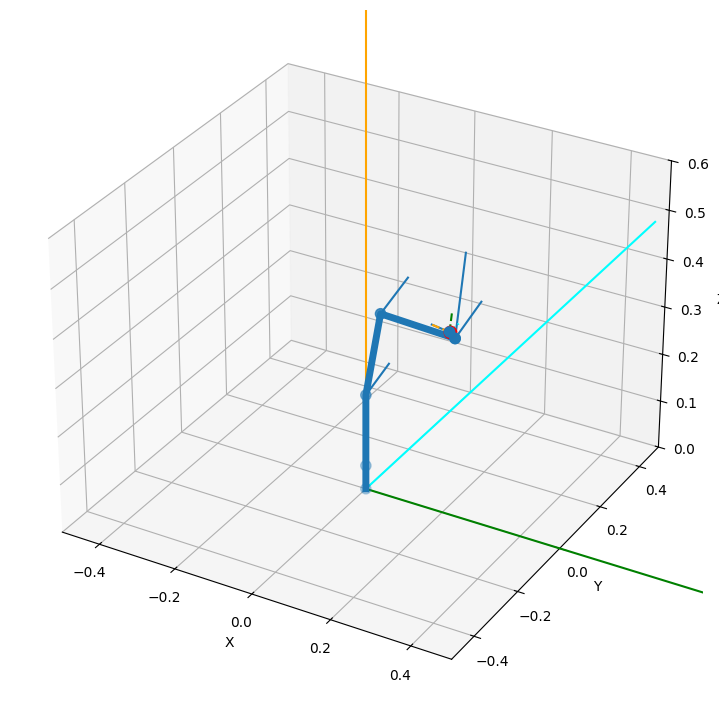

In [7]:
import numpy as np

# Define the two 3D points
point1 = np.array([0.0, 0.0, -0.5])
point2 = np.array([9.0, 9.0, 0.5])

# Define number of interpolation steps
num_steps = 10

# Create interpolation factors between 0 and 1
t_values = np.linspace(0, 1, num_steps)

# Interpolate linearly
interpolated_points = np.array([
    (1 - t) * point1 + t * point2 for t in t_values
])

# Print the result
print("Interpolated points:\n", interpolated_points)

# target positions.
# target_position = [ 0.175, 0.0, 0.380]
# target_position = [ 0.220, 0.0, 0.380]
target_position = [ 0.213, 0.0, 0.380]
# target_position = [ 0.0, 0.0, 0.0]
target_orientation = [0, 0, 0]
robot_angles = compute(target_position, target_orientation)
print(f"The angles of each joints are : {robot_angles}")